# What is the pay for different Data roles?

## Steps:

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analyst
3. Visualize for the highest paying skills and most demanding skills

In [20]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [21]:
df_DA_Salaries = df[(df['job_country'].isin(['United States', 'Mexico', 'Germany', 'UK']))].dropna(subset='salary_year_avg').copy()

In [22]:
job_titles = df_DA_Salaries['job_title_short'].value_counts().index[:6].to_list()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [26]:
df_top6 = df_DA_Salaries[df_DA_Salaries['job_title_short'].isin(job_titles)]

In [31]:
job_order = df_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

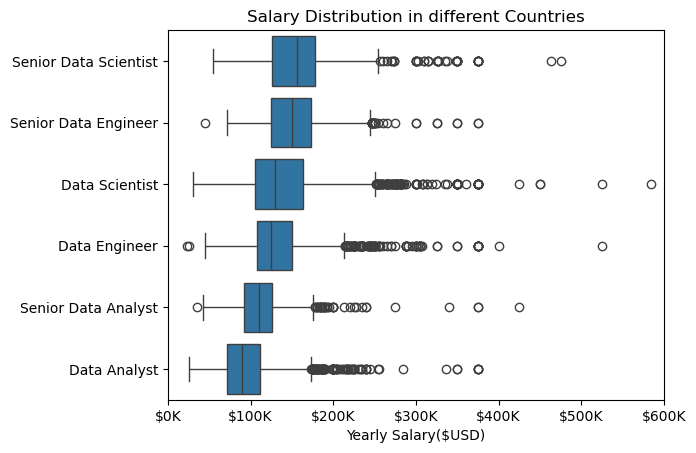

In [32]:
sns.boxplot(data=df_top6, x='salary_year_avg', y='job_title_short', order=job_order)

plt.title('Salary Distribution in different Countries')
plt.xlabel('Yearly Salary($USD)')
plt.ylabel('')
ticks_x = plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0,600000)
plt.show() #Removes "MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9;"